# Architecture meta-analysis

Goes beyond the per-region top-3 shortlists in `cross_folder_analysis.ipynb` to ask *systematic* questions:

1. **Is the metric (MAE vs RMSE) actually stable for ranking?** Most papers report RMSE; we've been ranking by MAE. Do the rankings match?
2. **Which architectural knobs help on average, across regions?** Average over all configs sharing a given knob value (e.g. all FiLM configs vs all concat configs) — much less noisy than picking out top-3.
3. **Are cross-region winners consistent or region-dependent?** Pairwise Spearman correlations between per-region rankings.
4. **What knobs do the per-region top-3 winners actually share?** Cross-checks the marginal-effect findings against the actual local-best configurations.

All analysis runs on the existing dataframe — no new model runs needed.

In [1]:
import sys, importlib
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import _helpers
importlib.reload(_helpers)

FOLDERS = [
    'snapshot_14y_eu', 'snapshot_14y_us', 'snapshot_14y_east_asia',
    'snapshot_14y_australia', 'snapshot_14y_southern_africa', 'snapshot_6y_eu',
]
SEEDS = [42, 123, 456]
TARGET_VARIABLES = ['t2m', 'wind']

df = _helpers.load_all_results(folders=FOLDERS, seeds=SEEDS)
df = _helpers.enrich_with_knobs(df)

# Quick sanity check on the enrichment
print(f'Rows: {len(df)}')
print(f'Targets: {sorted(df["target"].dropna().unique())}')
print(f'Kinds: {sorted(df["kind"].dropna().unique())}')
print()
print('TESSERA-VAE configs by knob value:')
vae_only = df[df['kind'] == 'tessera_vae']
for knob in ['latent_dim', 'proj_dim', 'proj_style', 'injection', 'elev', 'static']:
    counts = vae_only[knob].value_counts().to_dict()
    print(f'  {knob:<12} -> {counts}')


Rows: 2610
Targets: ['multitask', 't2m', 'wind']
Kinds: ['bilinear_baseline', 'era5_interp_baseline', 'persistence_baseline', 'tessera_vae']

TESSERA-VAE configs by knob value:
  latent_dim   -> {64.0: 1728, 16.0: 756}
  proj_dim     -> {8.0: 972, 0.0: 540, 16.0: 540, 32.0: 432}
  proj_style   -> {'linear': 1080, 'mlp': 864, 'direct': 540}
  injection    -> {'concat': 1296, 'film': 1188}
  elev         -> {'with': 1242, 'no': 1242}
  static       -> {'no': 2160, 'with': 324}


## 1. MAE vs RMSE rank consistency

Sanity check before relying on either metric: do they produce equivalent shortlists? If yes (Spearman ≈ 0.95+), our MAE-based shortlists generalise to the RMSE-based view that papers typically report. If no, we'd want to caveat results accordingly.

In [2]:
for var in TARGET_VARIABLES:
    print(f'=== {var}: MAE vs RMSE rank Spearman correlation across configs ===')
    rc = _helpers.mae_rmse_rank_consistency(df, variable=var)
    if rc.empty:
        print('  (no data)')
        continue
    print(rc.to_string(index=False))
    print(f'  Mean across folders: {rc["spearman_corr"].mean():.3f}')
    print()


=== t2m: MAE vs RMSE rank Spearman correlation across configs ===
                      folder  spearman_corr  n_configs
      snapshot_14y_australia       0.989393         46
      snapshot_14y_east_asia       0.989886         46
             snapshot_14y_eu       0.985692         46
snapshot_14y_southern_africa       0.985569         46
             snapshot_14y_us       0.989763         46
              snapshot_6y_eu       0.982979         46
  Mean across folders: 0.987

=== wind: MAE vs RMSE rank Spearman correlation across configs ===
                      folder  spearman_corr  n_configs
      snapshot_14y_australia       0.964601         46
      snapshot_14y_east_asia       0.980512         46
             snapshot_14y_eu       0.957940         46
snapshot_14y_southern_africa       0.992599         46
             snapshot_14y_us       0.974715         46
              snapshot_6y_eu       0.871477         46
  Mean across folders: 0.957



## 2. Marginal knob effects

For each architectural knob and each value of that knob, take the mean MAE across **all TESSERA-VAE configs** sharing that knob value, within each region. This averages over the other knobs, so noise from any single config doesn't dominate. Configs sharing a given knob value are typically 30+ runs (10 architectures × 3 seeds), so means are reasonably tight.

Read each plot as: *"holding the other knobs at their typical values, what's the average MAE for each setting of this knob?"* Lower = better. Differences smaller than the seed-level std bar are noise.

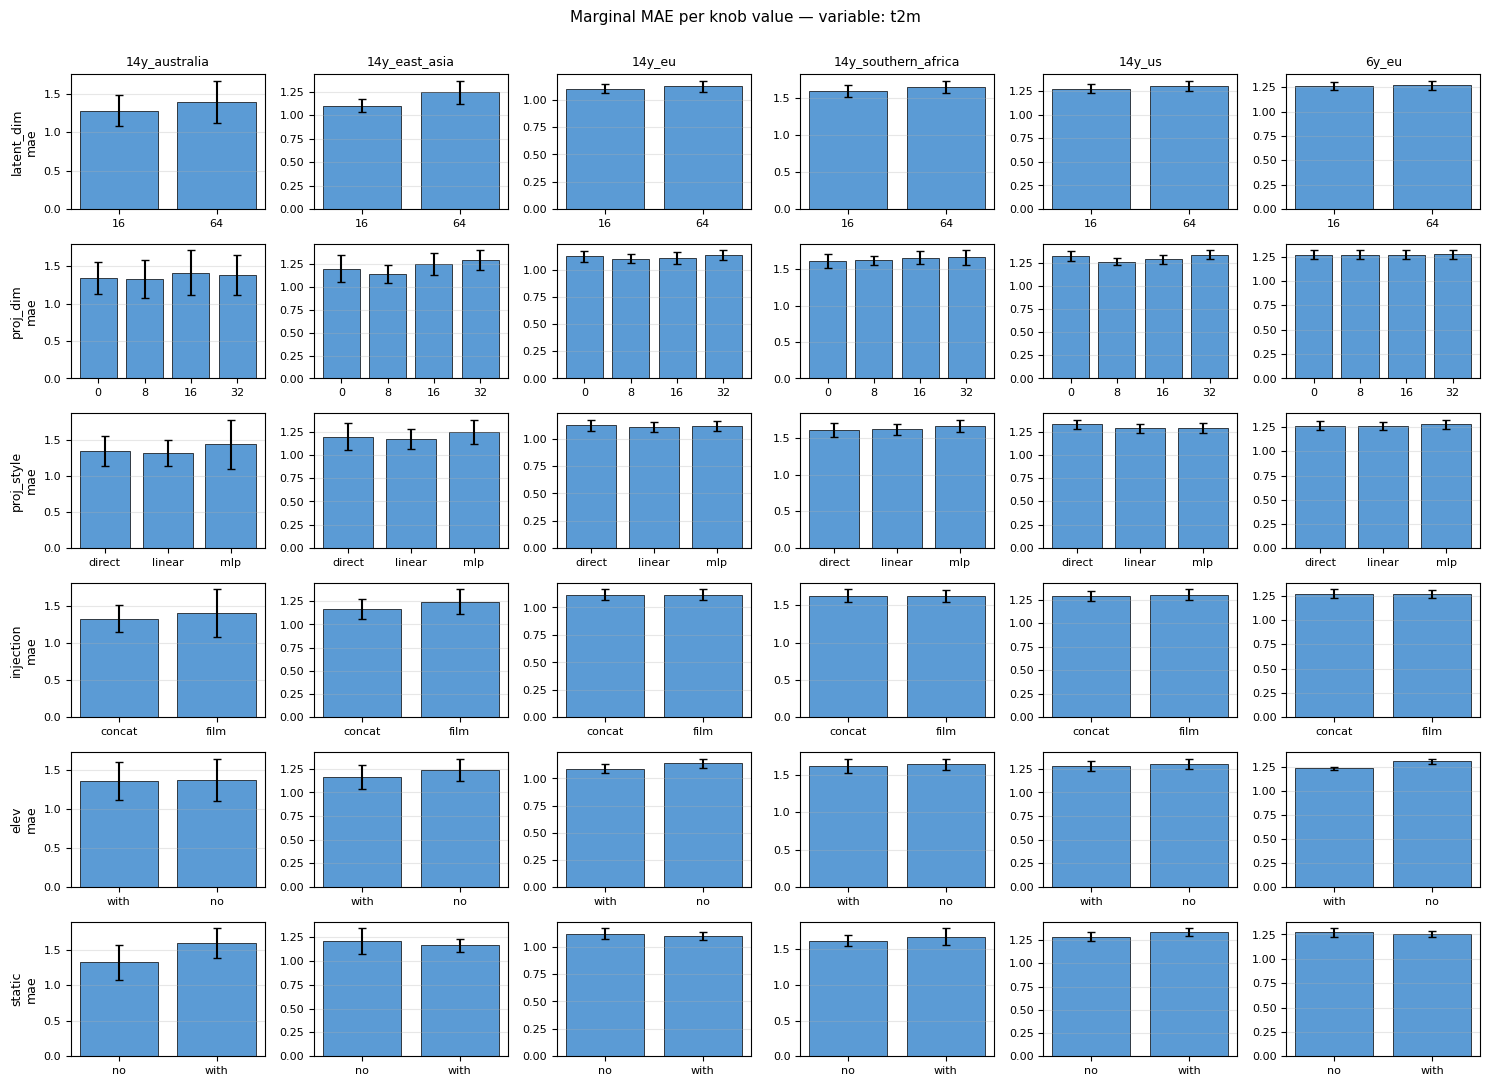

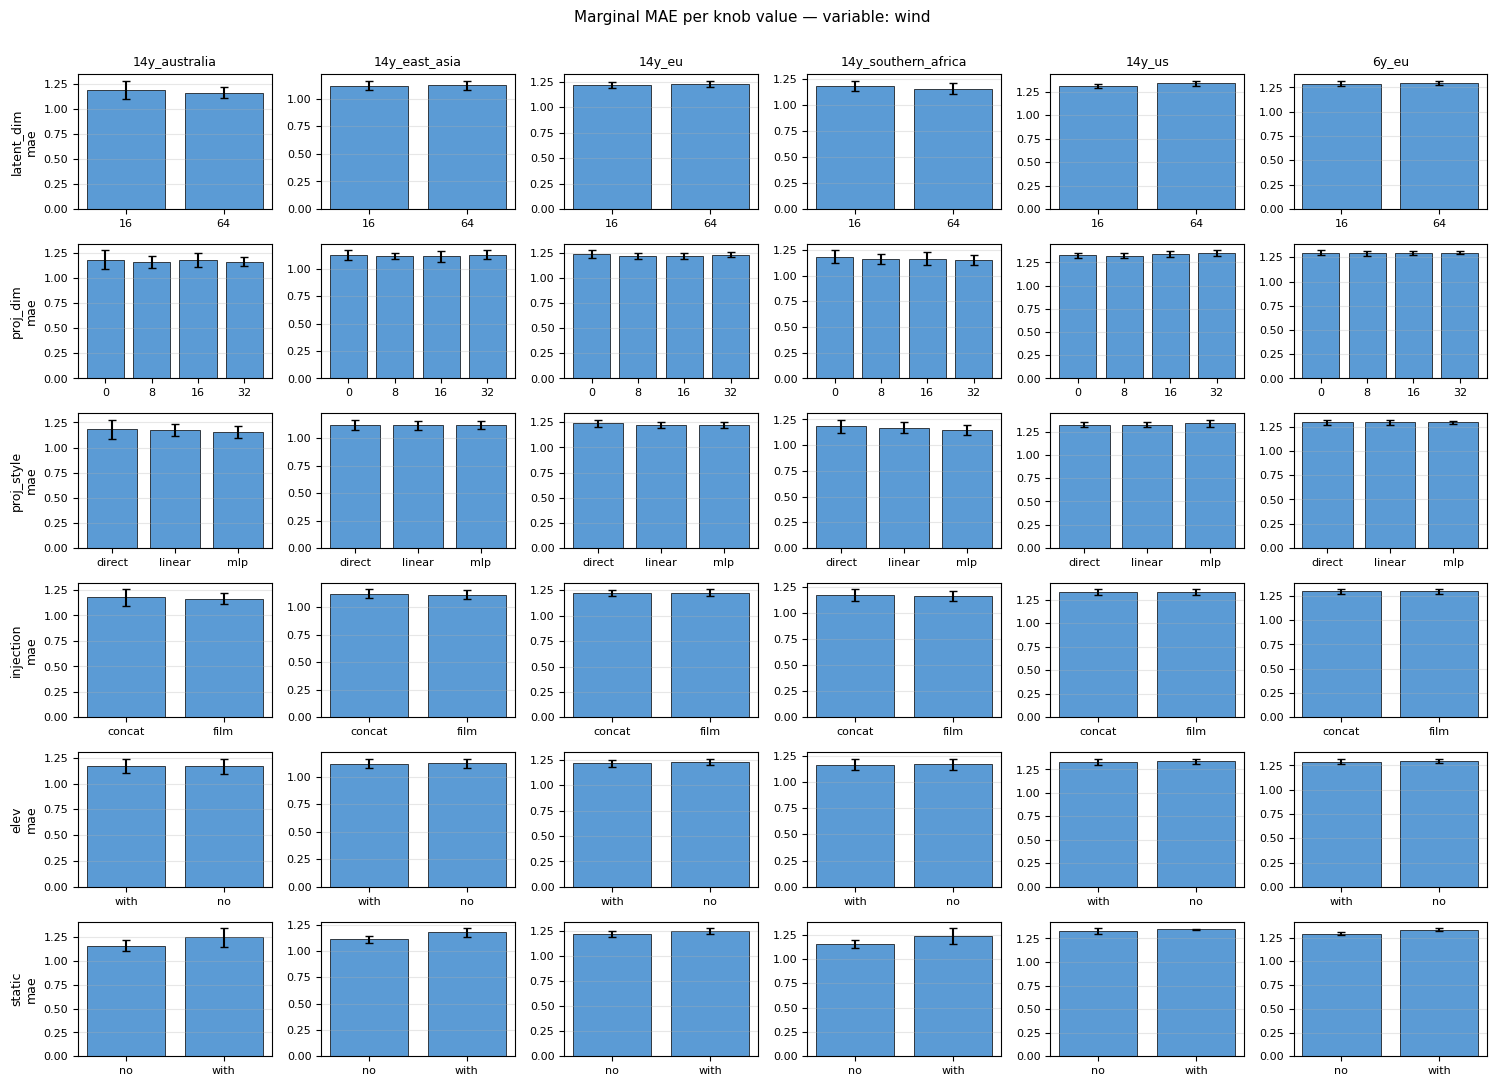

In [3]:
# One row of subplots per knob, one column per region. Bars within each
# subplot are the knob values, error bars are within-cell std.

def plot_marginal_effects(df, variable, metric='mae', figsize=None):
    me = _helpers.marginal_knob_effects(df, variable=variable, metric=metric, target=variable)
    if me.empty:
        print(f'No data for {variable}/{metric}')
        return
    knobs = list(_helpers.KNOB_VALUES.keys())
    folders = sorted(me['folder'].unique())
    n_knobs = len(knobs)
    n_folders = len(folders)
    if figsize is None:
        figsize = (2.5 * n_folders, 1.8 * n_knobs)
    fig, axes = plt.subplots(n_knobs, n_folders, figsize=figsize, sharex=False)
    if n_knobs == 1: axes = axes.reshape(1, -1)
    if n_folders == 1: axes = axes.reshape(-1, 1)

    for ki, knob in enumerate(knobs):
        for fi, folder in enumerate(folders):
            ax = axes[ki, fi]
            cell = me[(me['knob'] == knob) & (me['folder'] == folder)].copy()
            if cell.empty:
                ax.axis('off')
                continue
            # Order by configured KNOB_VALUES
            order = _helpers.KNOB_VALUES[knob]
            cell['order'] = cell['knob_value'].map({v: i for i, v in enumerate(order)})
            cell = cell.sort_values('order')
            x = np.arange(len(cell))
            ax.bar(x, cell['mean'], yerr=cell['std'], capsize=3, color='#5b9bd5', edgecolor='black', linewidth=0.5)
            ax.set_xticks(x)
            ax.set_xticklabels([str(v) for v in cell['knob_value']], fontsize=8)
            if fi == 0:
                ax.set_ylabel(f'{knob}\n{metric}', fontsize=9)
            if ki == 0:
                ax.set_title(folder.replace('snapshot_', ''), fontsize=9)
            ax.tick_params(axis='y', labelsize=8)
            ax.grid(axis='y', alpha=0.3)

    fig.suptitle(f'Marginal {metric.upper()} per knob value — variable: {variable}', y=1.001, fontsize=11)
    plt.tight_layout()
    plt.show()

for var in TARGET_VARIABLES:
    plot_marginal_effects(df, variable=var, metric='mae')


Interpreting the plots above — what to look for:

- **Consistent direction across folders**: if one knob value is always lower across all 6 columns, that's a robust effect.
- **Region-specific reversals**: if one folder shows the opposite direction from the others, there's a region interaction worth investigating.
- **Bars within seed-noise of each other**: the knob doesn't materially affect performance — pick whatever is simplest / cheapest.

Same plot but ranked by RMSE — sanity check that conclusions don't change.

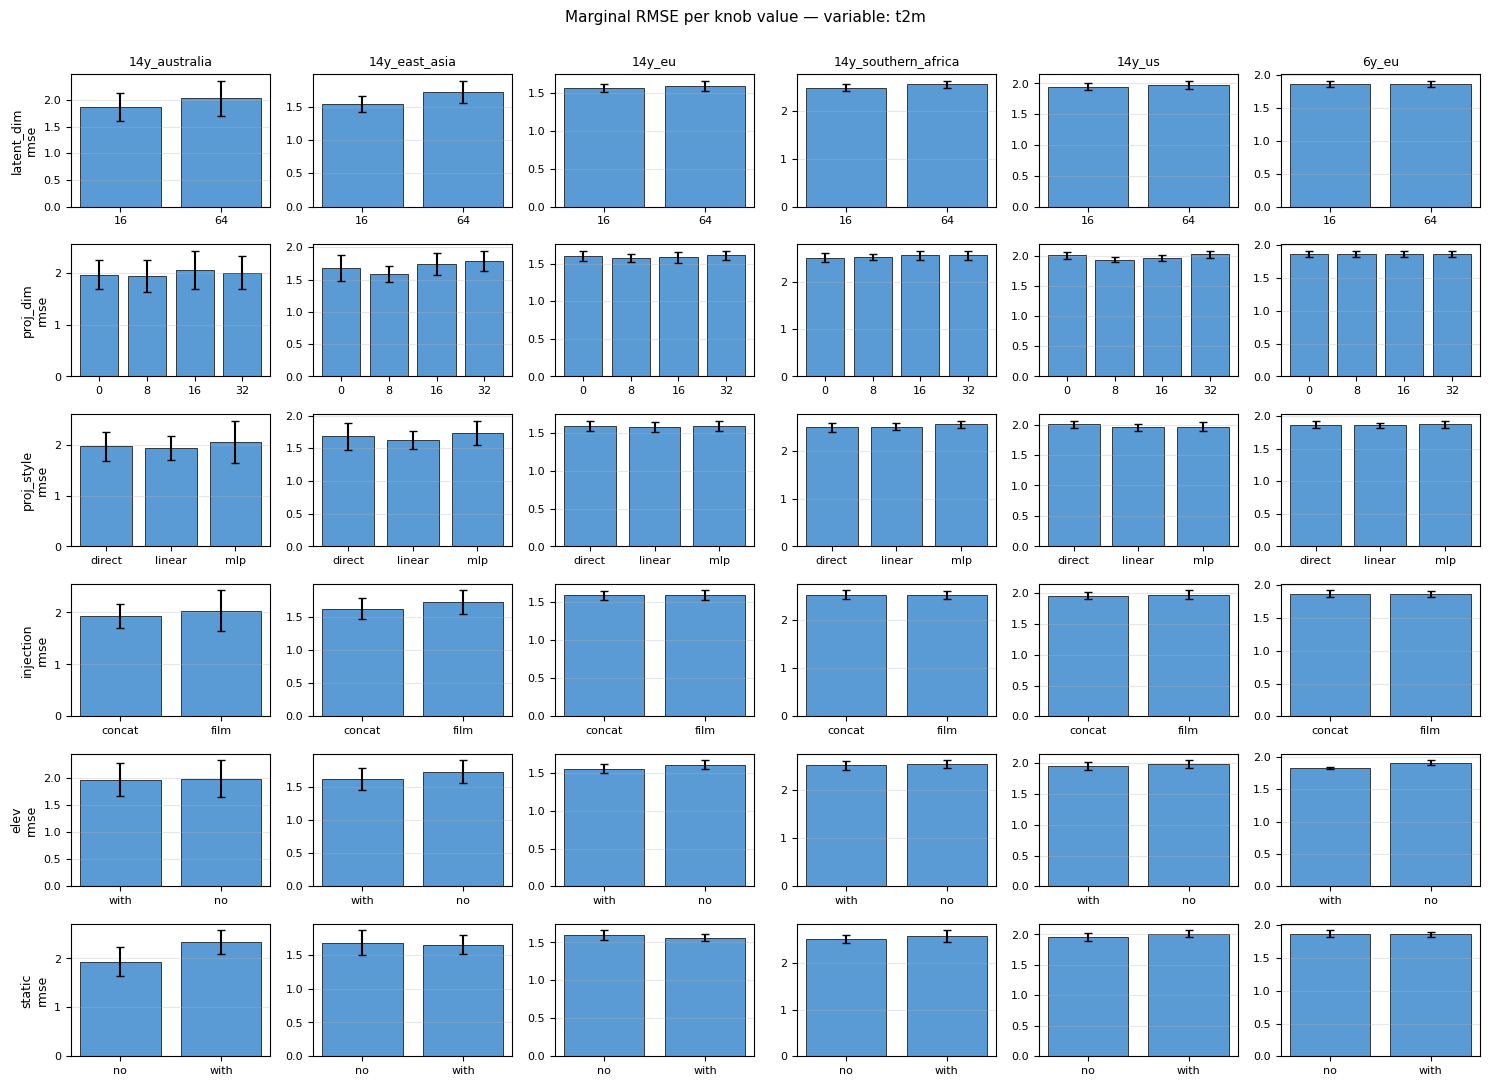

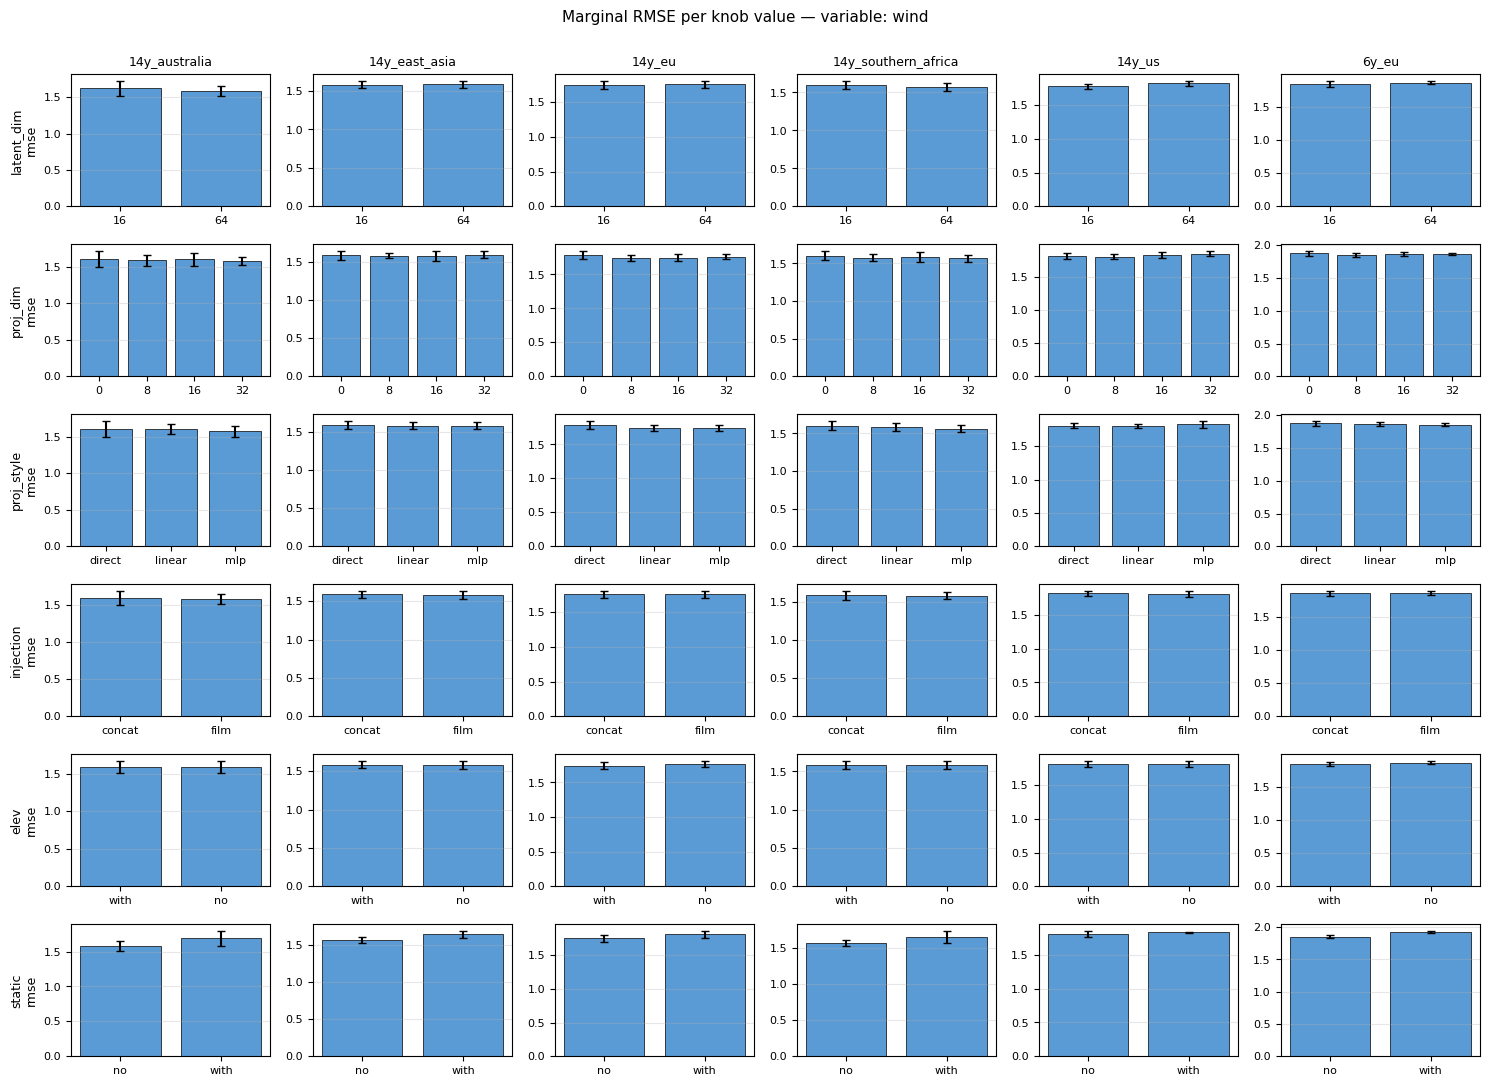

In [4]:
for var in TARGET_VARIABLES:
    plot_marginal_effects(df, variable=var, metric='rmse')


## 3. Cross-region rank stability

How well do per-region architecture rankings agree with each other? Each pair of folders gets a Spearman rank correlation over all TESSERA-VAE configs (averaged across seeds within each cell).

Interpretation:
- **High correlations (~0.8+)**: architecture choice is largely region-agnostic. The same configs tend to win everywhere. Pick a single architecture and it'll be near-optimal for any region.
- **Mid correlations (~0.4–0.7)**: there's both a global and a region-specific component. A reasonable architecture is okay everywhere but the optimal one depends on the region.
- **Low correlations (~0.0)**: rankings are essentially independent. Either there's a strong region interaction or the signal is noise.

In [5]:
for var in TARGET_VARIABLES:
    rcm = _helpers.rank_correlation_matrix(df, variable=var, metric='mae')
    if rcm.empty:
        print(f'{var}: (no data)')
        continue
    print(f'\n=== {var} — rank correlation across folders ===')
    print(rcm.round(3).to_string())
    # Off-diagonal mean as a single-number summary
    n = len(rcm)
    off_diag = rcm.values[~np.eye(n, dtype=bool)]
    print(f'Mean off-diagonal Spearman: {np.nanmean(off_diag):.3f}')



=== t2m — rank correlation across folders ===
source_folder                 snapshot_14y_australia  snapshot_14y_east_asia  snapshot_14y_eu  snapshot_14y_southern_africa  snapshot_14y_us  snapshot_6y_eu
source_folder                                                                                                                                               
snapshot_14y_australia                         1.000                   0.513            0.035                         0.498            0.416           0.090
snapshot_14y_east_asia                         0.513                   1.000            0.519                         0.598            0.573           0.540
snapshot_14y_eu                                0.035                   0.519            1.000                         0.316            0.290           0.721
snapshot_14y_southern_africa                   0.498                   0.598            0.316                         1.000            0.405           0.396
snapshot_14

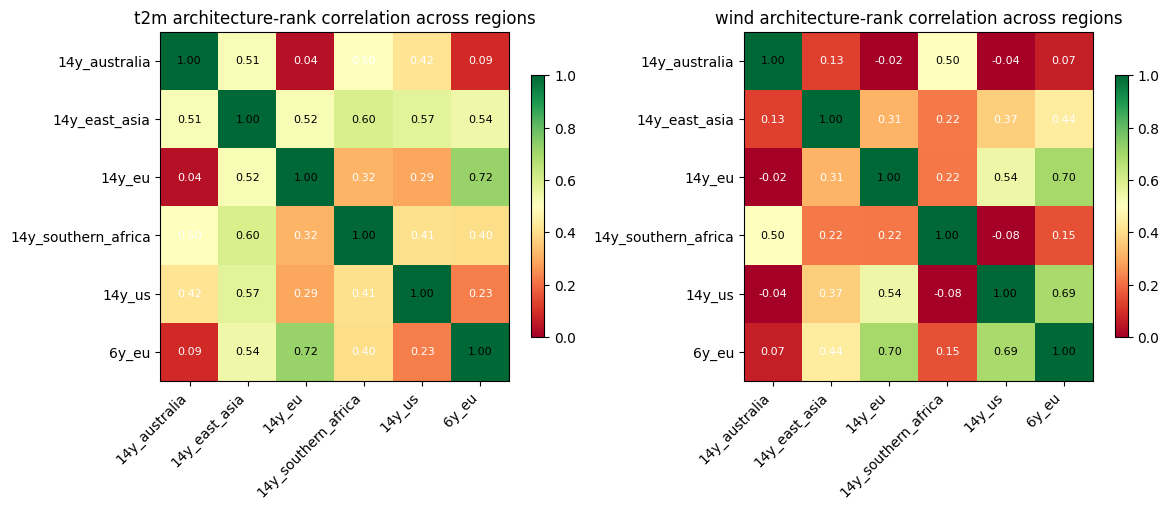

In [6]:
# Visualise as a heatmap, side by side for t2m and wind
fig, axes = plt.subplots(1, len(TARGET_VARIABLES), figsize=(6 * len(TARGET_VARIABLES), 5))
if len(TARGET_VARIABLES) == 1: axes = [axes]
for i, var in enumerate(TARGET_VARIABLES):
    rcm = _helpers.rank_correlation_matrix(df, variable=var, metric='mae')
    if rcm.empty:
        continue
    folder_labels = [f.replace('snapshot_', '') for f in rcm.columns]
    im = axes[i].imshow(rcm.values, vmin=0, vmax=1, cmap='RdYlGn')
    axes[i].set_xticks(range(len(rcm)))
    axes[i].set_yticks(range(len(rcm)))
    axes[i].set_xticklabels(folder_labels, rotation=45, ha='right')
    axes[i].set_yticklabels(folder_labels)
    axes[i].set_title(f'{var} architecture-rank correlation across regions')
    for r in range(len(rcm)):
        for c in range(len(rcm)):
            v = rcm.values[r, c]
            if not np.isnan(v):
                axes[i].text(c, r, f'{v:.2f}', ha='center', va='center',
                             color='black' if v > 0.5 else 'white', fontsize=8)
    fig.colorbar(im, ax=axes[i], shrink=0.7)
plt.tight_layout()
plt.show()


## 4. What do per-region top-3 winners actually share?

Reconnect the marginal-effect findings to actual local optima. For each (folder, variable), pull the top-3 architectures and tabulate their knob values.

In [7]:
for var in TARGET_VARIABLES:
    print(f'\n=== Top 3 {var} winners per region (single-task TESSERA-VAE only) ===')
    rows = []
    for folder in FOLDERS:
        sub = df[
            (df['kind'] == 'tessera_vae')
            & (df['target'] == var)
            & (df['source_folder'] == folder)
            & (df['static'] == 'no')  # main matrix only, exclude static-fields ablation
        ]
        if sub.empty:
            continue
        # Mean MAE per experiment across seeds
        per_exp = (
            sub.groupby(['experiment', 'latent_dim', 'proj_dim', 'proj_style', 'injection', 'elev'])
            [f'{var}_mae'].agg(['mean', 'std', 'count']).reset_index()
            .sort_values('mean')
            .head(3)
        )
        for rank, (_, row) in enumerate(per_exp.iterrows(), start=1):
            rows.append({
                'folder': folder.replace('snapshot_', ''),
                'rank': rank,
                'lat': int(row['latent_dim']),
                'proj': int(row['proj_dim']) if row['proj_dim'] > 0 else 'direct',
                'style': row['proj_style'],
                'inj': row['injection'],
                'elev': row['elev'],
                'mae': f"{row['mean']:.3f}±{row['std']:.3f}",
                'n_seeds': int(row['count']),
            })
    table = pd.DataFrame(rows)
    print(table.to_string(index=False))



=== Top 3 t2m winners per region (single-task TESSERA-VAE only) ===
             folder  rank  lat   proj  style    inj elev         mae  n_seeds
             14y_eu     1   16      8 linear concat with 1.040±0.010        3
             14y_eu     2   64      8 linear   film with 1.044±0.022        3
             14y_eu     3   64     32 linear   film with 1.067±0.032        3
             14y_us     1   64      8    mlp   film with 1.227±0.001        3
             14y_us     2   64     16 linear concat with 1.231±0.002        3
             14y_us     3   64      8 linear concat   no 1.238±0.003        3
      14y_east_asia     1   16      8 linear concat with 1.022±0.041        3
      14y_east_asia     2   16 direct direct concat with 1.027±0.008        3
      14y_east_asia     3   16      8 linear   film with 1.051±0.017        3
      14y_australia     1   16 direct direct   film with 1.146±0.021        3
      14y_australia     2   16      8 linear   film   no 1.159±0.050     

Cross-check this against the marginal-effect plots: if the marginals say (e.g.) FiLM is on average worse than concat, but the top-3 are dominated by FiLM configs, then FiLM has higher *variance* and the top-3 picks are exploiting noise. Conversely, if a knob has a clear marginal direction AND the top-3 align with that direction, the effect is robust.

## 5. Multi-task vs single-task knob comparison

Quick separate sanity check: do the same knob preferences hold for multi-task variants? The multi-task entries are evaluated on a slightly smaller test set (1–4% smaller per the `n_predictions` columns), but that's small enough that comparing knob marginal effects within multi-task vs within single-task is still informative.

In [8]:
for var in TARGET_VARIABLES:
    st = _helpers.marginal_knob_effects(df, variable=var, metric='mae', target=var)
    mt = _helpers.marginal_knob_effects(df, variable=var, metric='mae', target='multitask')
    if st.empty or mt.empty:
        print(f'{var}: incomplete data')
        continue
    # Combine, marking source
    st['mode'] = 'single-task'
    mt['mode'] = 'multi-task'
    combined = pd.concat([st, mt])
    # Pivot to a wide table for at-a-glance comparison: rows = (knob, value), cols = (folder, mode)
    pivot = combined.pivot_table(
        index=['knob', 'knob_value'],
        columns=['folder', 'mode'],
        values='mean',
    )
    print(f'\n=== {var} marginal MAE: single-task vs multi-task ===')
    print(pivot.round(3).to_string())



=== t2m marginal MAE: single-task vs multi-task ===
folder                snapshot_14y_australia             snapshot_14y_east_asia             snapshot_14y_eu             snapshot_14y_southern_africa             snapshot_14y_us             snapshot_6y_eu            
mode                              multi-task single-task             multi-task single-task      multi-task single-task                   multi-task single-task      multi-task single-task     multi-task single-task
knob       knob_value                                                                                                                                                                                                  
elev       no                          1.310       1.370                  1.253       1.242           1.222       1.142                        1.687       1.643           1.385       1.306          1.369       1.307
           with                        1.288       1.354                  1.211    

## Conclusions placeholder

After running the cells above, write up:

- **Robust knob effects** (consistent direction across regions, both metrics): list each knob with its preferred value and a one-line rationale.
- **Region-specific patterns** (knobs whose direction reverses or differs across regions): list with the region interactions seen.
- **Knobs that don't matter** (within-noise differences in marginal plot): list and note that simpler/cheaper choice is fine.
- **Implications for next steps**: e.g., "future runs should fix knob X at value V; we still need region-specific selection on knob Y".